In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


In [21]:
#Lets load the data 
ml = pd.read_csv('../data/features/train_features.csv')

In [22]:
ml['DateTime'] = pd.to_datetime(ml['DateTime']) #convert DateTime column to datetime format


In [33]:
print(ml.info())
ml = ml.fillna(0) #Fill any missing values with 0

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DateTime          48120 non-null  datetime64[us]
 1   Junction          48120 non-null  int64         
 2   Vehicles          48120 non-null  float64       
 3   ID                48120 non-null  int64         
 4   hour              48120 non-null  int64         
 5   day_of_week       48120 non-null  int64         
 6   day_of_month      48120 non-null  int64         
 7   month             48120 non-null  int64         
 8   year              48120 non-null  int64         
 9   week_of_year      48120 non-null  int64         
 10  quarter           48120 non-null  int64         
 11  is_weekend        48120 non-null  int64         
 12  is_rush_hour      48120 non-null  int64         
 13  is_night          48120 non-null  bool          
 14  hour_sin          48120 non-null 

In [34]:
#Define features and target
FEATURES = [
    'hour', 'day_of_week', 'month', 'year', 'quarter',
    'is_weekend', 'is_rush_hour', 'is_night', 'Junction',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h',
    'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_7d'
 ]
TARGET = 'Vehicles'

In [35]:
#Split the data into Train and Validation sets
split_date = ml['DateTime'].quantile(0.8) #80% for training, 20% for validation
print(f"Train cutoff: before {split_date}") 
print(f"Validation cutoff: after {split_date}\n")

train_data = ml[ml['DateTime'] < split_date] #Train on data before the cutoff date
val_data = ml[ml['DateTime'] >= split_date] #Validate on data after the cutoff date to simulate future predictions and avoid data leakage


X_train, y_train = train_data[FEATURES], train_data[TARGET] 
X_val, y_val = val_data[FEATURES], val_data[TARGET]

print(f"Train size: {len(train_data)} rows")
print(f"Validation size: {len(val_data)} rows")


Train cutoff: before 2017-03-22 17:12:00
Validation cutoff: after 2017-03-22 17:12:00

Train size: 38496 rows
Validation size: 9624 rows


In [36]:
#Evaluate a Helper Function

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{'='*40}")
    print(f"{name}")
    print(f" MAE: {mae:.2f} (avg error in vehicle count)")
    print(f" RMSE: {rmse:.2f} (penalizes larger errors more)")
    print(f" R²: {r2:.4f} (1.0 = perfect, 0 = useless)")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = [] #to store evaluation results for each model

#Model 1: Naive BaseLine (predicting mean)
naive_pred = np.full(len(y_val), y_train.mean()) #Predict the mean of the training target as a baseline
results.append(evaluate("Naive Baseline (Mean)", y_val, naive_pred))

# #Model 2: Linear Regression
lr = LinearRegression().fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_val, lr.predict(X_val)))

#Model 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate("Random Forest", y_val, rf.predict(X_val)))


Naive Baseline (Mean)
 MAE: 19.34 (avg error in vehicle count)
 RMSE: 28.41 (penalizes larger errors more)
 R²: -0.0888 (1.0 = perfect, 0 = useless)

Linear Regression
 MAE: 0.01 (avg error in vehicle count)
 RMSE: 0.02 (penalizes larger errors more)
 R²: 1.0000 (1.0 = perfect, 0 = useless)

Random Forest
 MAE: 0.93 (avg error in vehicle count)
 RMSE: 2.32 (penalizes larger errors more)
 R²: 0.9927 (1.0 = perfect, 0 = useless)


In [43]:
#XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1    
)

# Use callback-based early stopping to support xgboost versions that don't accept early_stopping_rounds in fit()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False)

results.append(evaluate("XGBoost", y_val, xgb_model.predict(X_val)))



XGBoost
 MAE: 1.66 (avg error in vehicle count)
 RMSE: 3.18 (penalizes larger errors more)
 R²: 0.9864 (1.0 = perfect, 0 = useless)


In [45]:
#LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
results.append(evaluate("LightGBM", y_val, lgb_model.predict(X_val)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1611
[LightGBM] [Info] Number of data points in the train set: 38496, number of used features: 23
[LightGBM] [Info] Start training from score 21.168927

LightGBM
 MAE: 0.88 (avg error in vehicle count)
 RMSE: 2.29 (penalizes larger errors more)
 R²: 0.9929 (1.0 = perfect, 0 = useless)


In [48]:
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\nModel Performance Comparison:")
display(results_df)


Model Performance Comparison:


,model,MAE,RMSE,R2
1,Linear Regression,0.012267,0.015582,1.000000
5,LightGBM,0.882024,2.293796,0.992901
2,Random Forest,0.931297,2.321135,0.992731
3,XGBoost,1.662881,3.179072,0.986364
4,XGBoost,1.662881,3.179072,0.986364
0,Naive Baseline (Mean),19.337284,28.407612,-0.088783


In [49]:
import joblib
import os

# Create the models folder if it doesn't exist
#os.makedirs('models', exist_ok=True)

# Save your trained LightGBM model and the feature list
joblib.dump(lgb_model, '../models/lightgbm_traffic_forecaster.pkl')
joblib.dump(FEATURES, '../models/feature_columns.pkl')

print("✅ Model and features saved successfully!")

✅ Model and features saved successfully!


In [50]:
#Evaluation

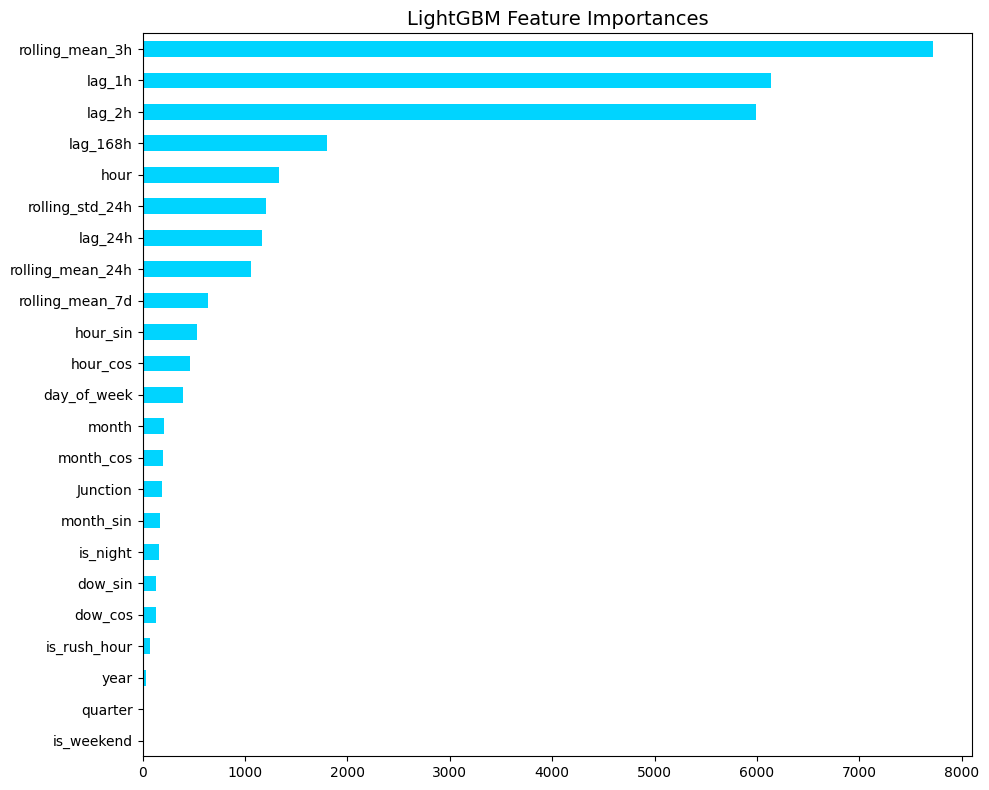

In [52]:
import matplotlib.pyplot as plt
#Feature Importance
# This asks LightGBM Which features were most important in making predictions
lgb_model = joblib.load('../models/lightgbm_traffic_forecaster.pkl')
FEATURES = joblib.load('../models/feature_columns.pkl')

importances = pd.Series(lgb_model.feature_importances_, index=FEATURES)
importances.sort_values(ascending=True).plot(
    kind='barh', figsize=(10, 8), color='#00d4ff'
)
plt.title('LightGBM Feature Importances', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/09_feature_importance.png', dpi=150)
plt.show()

In [53]:
# ── 2. Actual vs Predicted Plot (Using Validation Set) ─
# We plot the first 168 hours (7 days) of the validation set to visually check accuracy
for j in [1, 2, 3, 4]:
    # Filter the validation data for the specific junction
    mask = val['Junction'] == j
    y_true = y_val[mask]
    y_pred = lgb_model.predict(X_val[mask])

    plt.figure(figsize=(14, 4))
    # Plot real traffic data
    plt.plot(y_true.values[:168], label='Actual', color='#00d4ff', alpha=0.8)
    # Plot what the model predicted
    plt.plot(y_pred[:168], label='Predicted', color='#ff6b35', alpha=0.8, linestyle='--')
    
    plt.title(f'Junction {j} — 7 Day Forecast vs Actual (Validation Data)')
    plt.legend()
    plt.grid(alpha=0.2)
    
    # Notice the 'f' string syntax is corrected here!
    plt.savefig(f'reports/figures/06_junction{j}_forecast.png', dpi=150)
    plt.show()

NameError: name 'val' is not defined